# 🇳🇬 Nigeria — Climate Data Profiling, Cleaning & EDA

**10 Academy Week 0 Challenge | April 2026**

**Objective:** Profile, clean, and conduct exploratory data analysis on Nigeria's NASA POWER climate data (2015–2026) to surface key trends, seasonal patterns, and anomalies relevant to COP32 preparation.

**Data Source:** NASA POWER — daily observations at a representative location in Nigeria  
**Variables:** T2M, T2M_MAX, T2M_MIN, T2M_RANGE, PRECTOTCORR, RH2M, WS2M, WS2M_MAX, PS, QV2M

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

COUNTRY = 'Nigeria'
DATA_PATH = '../data/nigeria.csv'
CLEAN_PATH = '../data/nigeria_clean.csv'
print('Setup complete.')

Setup complete.


In [2]:
# Load CSV — skip NASA POWER comment header rows
df = pd.read_csv(DATA_PATH, comment='-', na_values=['-999', -999])
df['Country'] = COUNTRY

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (4108, 13)
Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


In [3]:
# Convert YEAR + DOY to proper datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df = df.sort_values('Date').reset_index(drop=True)

print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Total days: {len(df)}')
df[['Date', 'YEAR', 'DOY', 'Month', 'T2M', 'PRECTOTCORR']].head(10)

Date range: 2015-01-01 → 2026-03-31
Total days: 4108


,Date,YEAR,DOY,Month,T2M,PRECTOTCORR
0,2015-01-01,2015,1,1,25.23,0.0
1,2015-01-02,2015,2,1,26.16,0.0
2,2015-01-03,2015,3,1,25.66,0.0
3,2015-01-04,2015,4,1,24.11,0.0
4,2015-01-05,2015,5,1,23.40,0.0
5,2015-01-06,2015,6,1,22.66,0.0
6,2015-01-07,2015,7,1,23.53,0.0
7,2015-01-08,2015,8,1,24.06,0.0
8,2015-01-09,2015,9,1,23.09,0.0
9,2015-01-10,2015,10,1,21.71,0.0


In [4]:
# Replace -999 sentinel values with NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns
sentinel_count = (df[numeric_cols] == -999).sum().sum()
df[numeric_cols] = df[numeric_cols].replace(-999, np.nan)
print(f'Replaced {sentinel_count} sentinel -999 values with NaN')

Replaced 0 sentinel -999 values with NaN


In [5]:
# Duplicate check
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dropped {dupes} duplicates.')

Duplicate rows: 0


In [6]:
# Summary statistics
df.describe().round(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00
mean,2020.13,180.12,26.66,28.91,24.89,4.03,4.21,85.24,2.22,2.90,100.83,18.56,6.42
std,3.25,106.29,1.12,1.29,1.40,1.40,7.27,5.45,0.59,0.70,0.17,1.65,3.48
min,2015.00,1.00,21.12,25.26,15.17,1.16,0.00,54.40,0.74,1.29,100.38,9.43,1.00
25%,2017.00,86.00,25.72,27.92,24.10,3.09,0.33,83.93,1.77,2.37,100.71,17.97,3.00
50%,2020.00,179.00,26.82,28.99,25.10,3.77,1.84,86.35,2.20,2.81,100.82,18.84,6.00
75%,2023.00,272.00,27.54,29.91,25.86,4.60,5.20,88.50,2.63,3.39,100.95,19.57,9.00
max,2026.00,366.00,29.29,32.88,27.79,11.73,166.10,93.79,4.78,6.00,101.35,21.74,12.00


In [7]:
# Missing value report
total = len(df)
missing = df.isnull().sum()
pct = (missing / total * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(missing_report)

high_missing = missing_report[missing_report['Missing %'] > 5]
if len(high_missing) > 0:
    print(f'\n⚠️  Columns with >5% missing: {list(high_missing.index)}')
    print('These may indicate instrument downtime or satellite coverage gaps.')
else:
    print('\n✅ No columns exceed 5% missing values.')

Columns with missing values:


,Missing Count,Missing %



✅ No columns exceed 5% missing values.


In [8]:
# Z-score outlier detection
z_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
available_z = [c for c in z_cols if c in df.columns]

outlier_counts = {}
for col in available_z:
    clean_series = df[col].dropna()
    z = np.abs(stats.zscore(clean_series))
    flagged = (z > 3).sum()
    outlier_counts[col] = flagged

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count (|Z|>3)'])
print('Outlier detection (Z-score threshold = 3):')
display(outlier_df)
print(f'\nTotal flagged values: {outlier_df["Outlier Count (|Z|>3)"].sum()}')

Outlier detection (Z-score threshold = 3):


,Outlier Count (|Z|>3)
T2M,10
T2M_MAX,1
T2M_MIN,68
PRECTOTCORR,75
RH2M,128
WS2M,5
WS2M_MAX,10



Total flagged values: 297


In [9]:
# Cap outliers at 1st/99th percentile (Winsorization)
for col in available_z:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p01, upper=p99)

print('Outliers capped at 1st/99th percentile for all target columns.')

Outliers capped at 1st/99th percentile for all target columns.


In [10]:
# Handle missing values: drop rows with >30% missing, then forward-fill
weather_cols = [c for c in ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M'] if c in df.columns]

null_ratio = df[weather_cols].isnull().mean(axis=1)
rows_before = len(df)
df = df[null_ratio <= 0.30].reset_index(drop=True)
print(f'Dropped {rows_before - len(df)} rows with >30% missing values.')

df[weather_cols] = df[weather_cols].ffill()
print(f'Remaining NaNs after forward-fill: {df[weather_cols].isnull().sum().sum()}')

Dropped 0 rows with >30% missing values.
Remaining NaNs after forward-fill: 0


In [11]:
# Export cleaned data
df.to_csv(CLEAN_PATH, index=False)
print(f'✅ Cleaned data exported to {CLEAN_PATH}')
print(f'Final shape: {df.shape}')

✅ Cleaned data exported to ../data/nigeria_clean.csv
Final shape: (4108, 15)


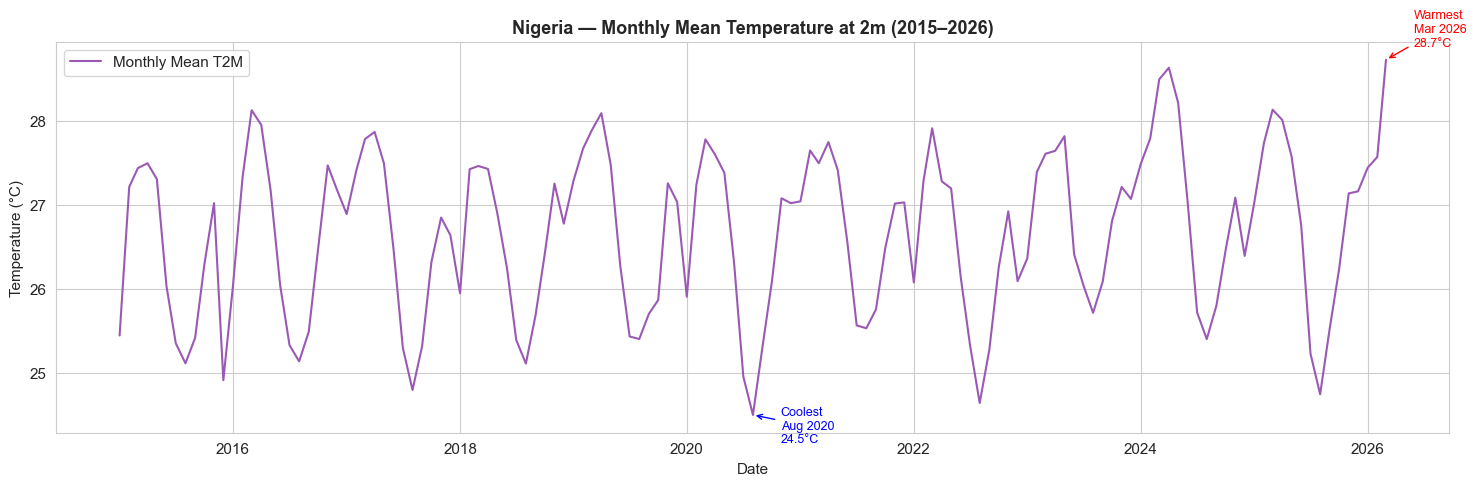

Saved temperature time series chart.


In [12]:
# Monthly average temperature over full period
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    T2M_mean=('T2M', 'mean'),
    PREC_total=('PRECTOTCORR', 'sum')
).reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly['Date'], monthly['T2M_mean'], color='#9B59B6', linewidth=1.5, label='Monthly Mean T2M')

# Annotate warmest and coolest months
warm_idx = monthly['T2M_mean'].idxmax()
cool_idx = monthly['T2M_mean'].idxmin()
ax.annotate(f"Warmest\n{monthly.loc[warm_idx,'Date'].strftime('%b %Y')}\n{monthly.loc[warm_idx,'T2M_mean']:.1f}°C",
            xy=(monthly.loc[warm_idx,'Date'], monthly.loc[warm_idx,'T2M_mean']),
            xytext=(20, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.annotate(f"Coolest\n{monthly.loc[cool_idx,'Date'].strftime('%b %Y')}\n{monthly.loc[cool_idx,'T2M_mean']:.1f}°C",
            xy=(monthly.loc[cool_idx,'Date'], monthly.loc[cool_idx,'T2M_mean']),
            xytext=(20, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=9)

ax.set_title('Nigeria — Monthly Mean Temperature at 2m (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('../dashboard_screenshots/nigeria_temp_timeseries.png', dpi=150)
plt.show()
print('Saved temperature time series chart.')

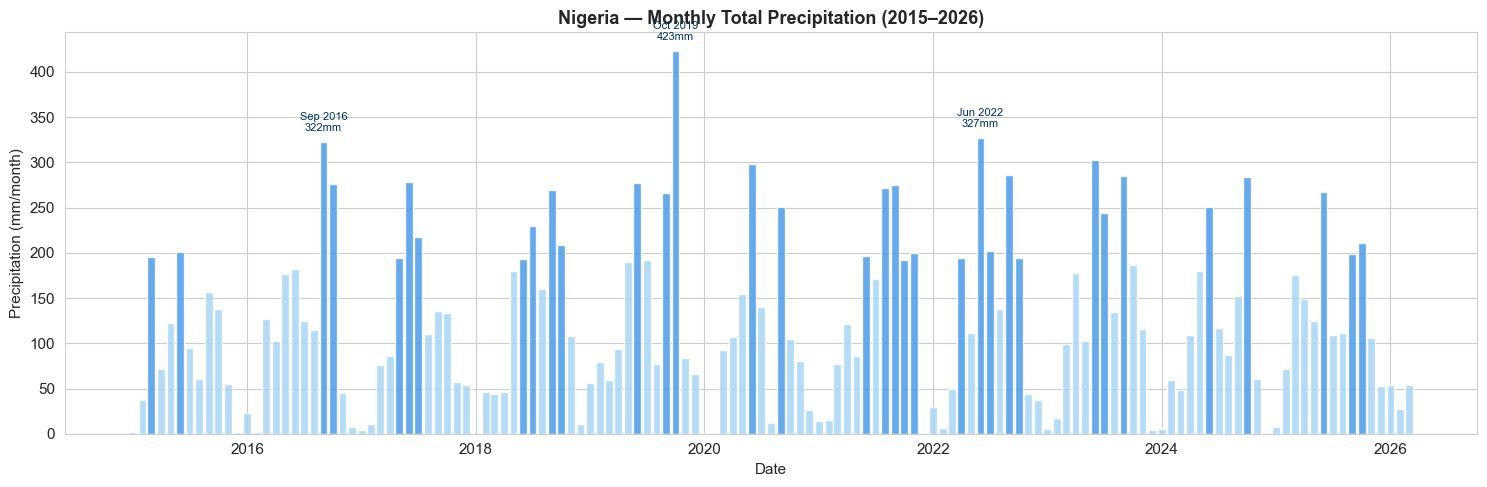

In [13]:
# Monthly total precipitation bar chart
fig, ax = plt.subplots(figsize=(15, 5))
colors = ['#4C9BE8' if v >= monthly['PREC_total'].quantile(0.75) else '#A8D5F5' for v in monthly['PREC_total']]
ax.bar(monthly['Date'], monthly['PREC_total'], color=colors, width=25, alpha=0.85)

# Annotate peak months
top3 = monthly.nlargest(3, 'PREC_total')
for _, row in top3.iterrows():
    ax.annotate(f"{row['Date'].strftime('%b %Y')}\n{row['PREC_total']:.0f}mm",
                xy=(row['Date'], row['PREC_total']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#003366')

ax.set_title('Nigeria — Monthly Total Precipitation (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm/month)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../dashboard_screenshots/nigeria_precip_barchart.png', dpi=150)
plt.show()

In [14]:
print('\n=== NIGERIA EDA SUMMARY ===')
print(f'Period: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Total clean observations: {len(df)}')
print(f'Mean T2M: {df["T2M"].mean():.2f}°C | Max T2M_MAX: {df["T2M_MAX"].max():.2f}°C')
print(f'Total precipitation: {df["PRECTOTCORR"].sum():.0f} mm over period')
print(f'Extreme heat days (T2M_MAX > 35°C): {(df["T2M_MAX"] > 35).sum()}')
print(f'Dry days (PRECTOTCORR < 1mm): {(df["PRECTOTCORR"] < 1).sum()} ({((df["PRECTOTCORR"] < 1).mean())*100:.1f}%)')
print(f'Cleaned CSV saved to: {CLEAN_PATH}')


=== NIGERIA EDA SUMMARY ===
Period: 2015-01-01 to 2026-03-31
Total clean observations: 4108
Mean T2M: 26.66°C | Max T2M_MAX: 31.74°C
Total precipitation: 16617 mm over period
Extreme heat days (T2M_MAX > 35°C): 0
Dry days (PRECTOTCORR < 1mm): 1595 (38.8%)
Cleaned CSV saved to: ../data/nigeria_clean.csv
